In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import cv2

sys.path.append("../src")

from data_loader import load_data

In [3]:
DATA_DIR = "../data/archive"

POSITIVE_PATH = os.path.join(DATA_DIR, "Positive")
NEGATIVE_PATH = os.path.join(DATA_DIR, "Negative")

images, labels = load_data(POSITIVE_PATH, NEGATIVE_PATH, 4000)

print("Number of images:", len(images))
print("Number of labels:", len(labels))
print("First image shape:", images[0].shape)

Number of images: 8000
Number of labels: 8000
First image shape: (227, 227, 3)


In [4]:
#the model is too slow so i will resize the images.
IMG_SIZE = (128, 128)
X = []

for image in images:
    # OpenCV charge en BGR, on convertit en RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize pour rendre toutes les images compatibles avec le CNN
    image_resized = cv2.resize(image_rgb, IMG_SIZE)

    # Normalisation des pixels entre 0 et 1
    image_normalized = image_resized.astype("float32") / 255.0

    X.append(image_normalized)

X = np.array(X, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Pixel min:", X.min())
print("Pixel max:", X.max())
print("Labels:", np.unique(y, return_counts=True))

X shape: (8000, 128, 128, 3)
y shape: (8000,)
Pixel min: 0.0
Pixel max: 1.0
Labels: (array([0, 1], dtype=int32), array([4000, 4000]))


In [6]:
# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (5600, 128, 128, 3) (5600,)
Validation: (1200, 128, 128, 3) (1200,)
Test: (1200, 128, 128, 3) (1200,)


In [7]:
def create_simple_cnn():
    model = Sequential([
        
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(2, activation="softmax")   # Output layer (Positive / Negative)
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [9]:
model = create_simple_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)
model.save("../models/cnn_model.keras")

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 250ms/step - accuracy: 0.8907 - loss: 0.2427 - val_accuracy: 0.9267 - val_loss: 0.2200
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 258ms/step - accuracy: 0.9807 - loss: 0.0634 - val_accuracy: 0.9783 - val_loss: 0.0634
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 50s 286ms/step - accuracy: 0.9907 - loss: 0.0347 - val_accuracy: 0.9875 - val_loss: 0.0384
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 260ms/step - accuracy: 0.9923 - loss: 0.0263 - val_accuracy: 0.9900 - val_loss: 0.0440
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 244ms/step - accuracy: 0.9936 - loss: 0.0184 - val_accuracy: 0.9867 - val_loss: 0.0416
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 260ms/step - accuracy: 0.9939 - loss: 0.0218 - val_accuracy: 0.9925 - val_loss: 0.0319
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 276ms/step - accuracy: 0.9948 - loss: 0.0164 - val_accuracy: 0.9925 - val_loss: 0.0336
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 255ms/step - accuracy: 0.9950 - loss: 0

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9900 - loss: 0.0534
Test Loss: 0.0534
Test Accuracy: 0.9900


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
Generating Confusion Matrix...


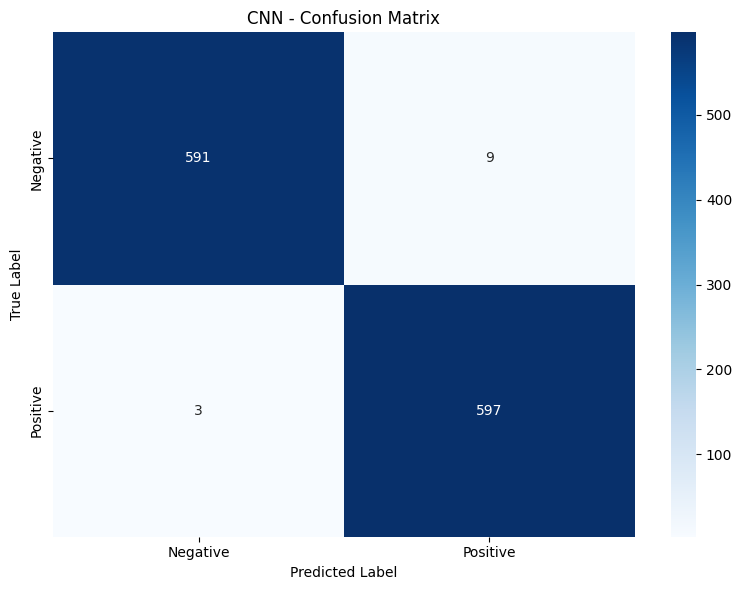

Generating Classification Report...
              precision    recall  f1-score   support

    Negative       0.99      0.98      0.99       600
    Positive       0.99      0.99      0.99       600

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



In [12]:
class_names = ["Negative", "Positive"]

# Predictions
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
print("Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Classification Report
print("Generating Classification Report...")
report = classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names
)

print(report)

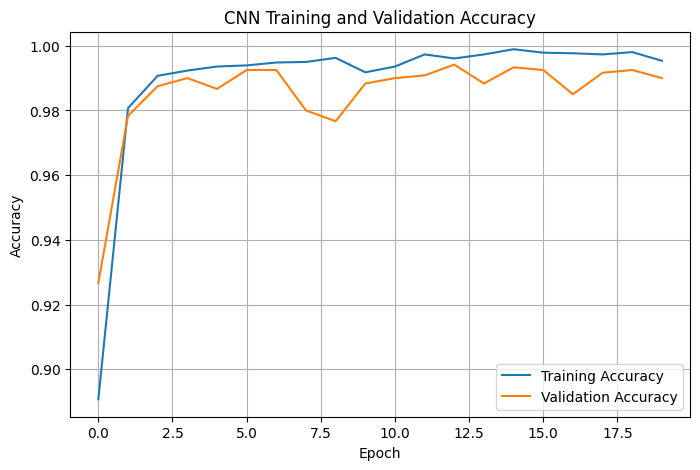

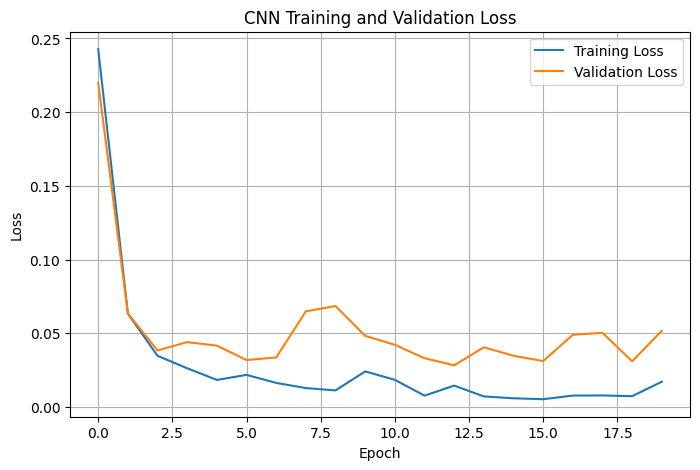

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()